# 1 · Quickstart

This notebook runs the LiFePO₄ half-cell model from Python. The model is a porous LiFePO₄ cathode against a lithium-foil counter electrode, with a separator between them. The same model is also available as a self-contained Fortran program (`fortran/lfp.f90`) and C++ program (`cpp/lfp.cpp`), which read the same input file.

All parameters are the model's defaults (see `docs/parameters.md`), for illustration only. They are not fitted to any particular cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lfp_model.params import Params
from lfp_model.simulate import run

## A constant-current discharge

`mode="corrected"` is the recommended model: it fixes the defects of the original research code listed in `docs/deviations.md`. The run stops at the lower voltage cutoff `V_min` (2.5 V by default).

cutoff_low after 3599 time steps


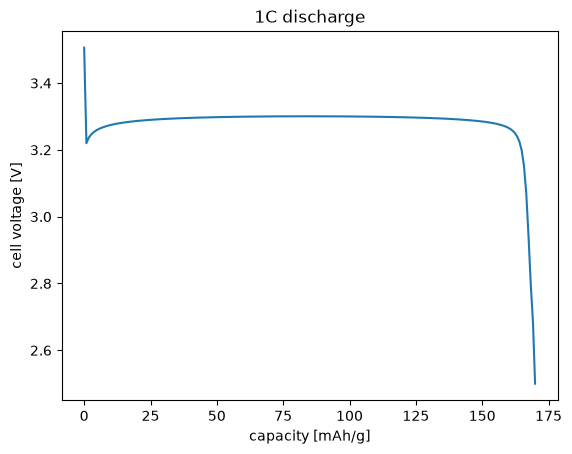

In [2]:
p = Params(mode="corrected", C_rate=1.0)
r = run(p)
a = r.array          # columns: t [h], V, equivalents, Li eta [mV], Li i0 [mA/cm2], c at x=0, I [mA/cm2], step
print(r.exit_reason, f"after {r.steps} time steps")

capacity = a[:, 2] * p.F / (p.M * 3.6)      # electron equivalents -> mAh/g
plt.plot(capacity, a[:, 1])
plt.xlabel("capacity [mAh/g]"); plt.ylabel("cell voltage [V]"); plt.title("1C discharge")
plt.show()

## Faithful and corrected modes

`Params.faithful()` reproduces the original program exactly. That includes ending the discharge on a numerical failure (NaN) rather than at a cutoff, and a different lithium-electrode overpotential (deviation D-12), which accounts for most of the voltage difference here.

faithful run ended with: nan


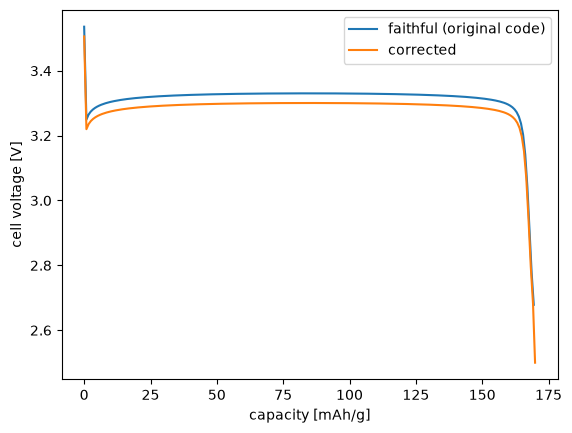

In [3]:
rf = run(Params.faithful(C_rate=1.0))
af = rf.array
print("faithful run ended with:", rf.exit_reason)
ok = np.isfinite(af[:, 1])
plt.plot(af[ok, 2] * p.F / (p.M * 3.6), af[ok, 1], label="faithful (original code)")
plt.plot(capacity, a[:, 1], label="corrected")
plt.xlabel("capacity [mAh/g]"); plt.ylabel("cell voltage [V]"); plt.legend(); plt.show()

## Running from an input file

The input file `input/default.nml` is shared by all three implementations:

```sh
python -m lfp_model input/default.nml        # Python
build/fortran/lfp_f input/default.nml        # Fortran (cmake --build build)
build/cpp/lfp_cpp   input/default.nml        # C++
```

Each writes `Time_Voltage.txt`. From Python you can also load the file and change values:

In [4]:
from pathlib import Path
from lfp_model.namelist import load

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
p_file, extra = load(root / "input" / "default.nml")
print(p_file.mode, p_file.C_rate, extra)
r2 = run(p_file.with_(mode="corrected", C_rate=2.0))
print(r2.exit_reason, f"final capacity {r2.array[-1, 2] * p.F / (p.M * 3.6):.1f} mAh/g")

corrected 1.0 {'file': 'Time_Voltage.txt'}
cutoff_low final capacity 169.9 mAh/g
